## Imports

In [1]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, roc_auc_score, classification_report, f1_score
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

from dotenv import load_dotenv
load_dotenv()

True

## Load clean Dataset

In [2]:
USE_S3 = os.getenv('USE_S3', 'false').lower() == 'true'
S3_BUCKET = os.getenv('S3_BUCKET', '')

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '../data')

if USE_S3:
    df = pd.read_csv(f's3://{S3_BUCKET}/cleaned_data.csv')
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))

print(f'Shape of the data : {df.shape}')
df.head()

Shape of the data : (13690540, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0


## Split by User

In [3]:
df = df.sample(1000000, random_state=42) # Select a smaller dataset with "Sample"

# Split by user : 80% Train, 20% Test
train_users, test_users = train_test_split(df["user_id"].unique(), test_size=0.2, random_state=42)
train_df = df[df["user_id"].isin(train_users)]
test_df = df[df["user_id"].isin(test_users)]

## Features and Target

In [4]:
features = [
    "add_to_cart_order",
    "aisle_id",
    "department_id",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "user_id",
    "product_id"
]

X_train = train_df[features]
y_train = train_df["reordered"]
X_test = test_df[features]
y_test = test_df["reordered"]

print(f"Train dataset : {X_train.shape}")
print(f"Test dataset : {X_test.shape}")

Train dataset : (800359, 9)
Test dataset : (199641, 9)


## Feature engineering

### User features

In [5]:
# Feature 1
# Add the number of order by user
user_total_orders = (X_train.groupby("user_id")["order_number"].max())

X_train["user_total_orders"] = X_train["user_id"].map(user_total_orders)
X_test["user_total_orders"] = X_test["user_id"].map(user_total_orders)

# Feature 2 
# Add the average time between 2 orders by user
user_avg_days_between_orders = (X_train.groupby("user_id")["days_since_prior_order"].mean())

X_train["user_avg_days_between_orders"] = X_train["user_id"].map(user_avg_days_between_orders)
X_test["user_avg_days_between_orders"] = X_test["user_id"].map(user_avg_days_between_orders)

X_train.head()

/var/folders/tg/g7wmflnj5qj88rgh57c80w7w0000gn/T/ipykernel_3999/402785621.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["user_total_orders"] = X_train["user_id"].map(user_total_orders)
/var/folders/tg/g7wmflnj5qj88rgh57c80w7w0000gn/T/ipykernel_3999/402785621.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["user_total_orders"] = X_test["user_id"].map(user_total_orders)
/var/folders/tg/g7wmflnj5qj88rgh57c80w7w0000gn/T/ipykernel_3999/402785621.py:12: SettingWithCopyWarning: 
A value is

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders
6045688,10,21,16,5,4,12,22.0,183652,40619,15,12.666667
4897765,5,83,4,22,6,23,14.0,115607,13629,22,8.000000
12592567,3,83,4,59,5,19,3.0,71106,44359,70,5.058824
9471652,4,92,18,5,6,9,8.0,167495,49583,45,5.657143
10963593,8,108,16,1,1,15,0.0,44312,13083,28,9.272727


### Product features

In [6]:
# Feature 3
# Add how many times the product has been sold
product_order_count = (X_train.groupby("product_id")["product_id"].count())

X_train["product_order_count"] = X_train["product_id"].map(product_order_count)
X_test["product_order_count"] = X_test["product_id"].map(product_order_count)

# Feature 4
# Add the average position of the product in the cart
product_avg_cart_position = (X_train.groupby("product_id")["add_to_cart_order"].mean())

X_train["product_avg_cart_position"] = X_train["product_id"].map(product_avg_cart_position)
X_test["product_avg_cart_position"] = X_test["product_id"].map(product_avg_cart_position)

# Feature 5
# Add the reorder rate per product
product_reorder_rate = df.groupby("product_id")["reordered"].mean()

X_train["product_reorder_rate"] = X_train["product_id"].map(product_reorder_rate)
X_test["product_reorder_rate"] = X_test["product_id"].map(product_reorder_rate)

X_train.head()

/var/folders/tg/g7wmflnj5qj88rgh57c80w7w0000gn/T/ipykernel_3999/1159640626.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["product_order_count"] = X_train["product_id"].map(product_order_count)
/var/folders/tg/g7wmflnj5qj88rgh57c80w7w0000gn/T/ipykernel_3999/1159640626.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["product_order_count"] = X_test["product_id"].map(product_order_count)
/var/folders/tg/g7wmflnj5qj88rgh57c80w7w0000gn/T/ipykernel_3999/1159640626.py:12: SettingWithCopyWar

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders,product_order_count,product_avg_cart_position,product_reorder_rate
6045688,10,21,16,5,4,12,22.0,183652,40619,15,12.666667,16,10.062500,0.294118
4897765,5,83,4,22,6,23,14.0,115607,13629,22,8.000000,422,10.137441,0.692022
12592567,3,83,4,59,5,19,3.0,71106,44359,70,5.058824,1636,9.350856,0.635282
9471652,4,92,18,5,6,9,8.0,167495,49583,45,5.657143,52,11.846154,0.557377
10963593,8,108,16,1,1,15,0.0,44312,13083,28,9.272727,164,8.225610,0.623810


### User x Product features

In [7]:
# Feature 6
# Add the user-product order count
user_product_order_count = (X_train.groupby(["user_id","product_id"])["order_number"].count())

X_train["user_product_order_count"] = (X_train.set_index(["user_id","product_id"]).index.map(user_product_order_count))
X_test["user_product_order_count"] = (X_test.set_index(["user_id","product_id"]).index.map(user_product_order_count))

# Feature 7
# Add the last order for each user-product
user_product_last_order = (X_train.groupby(["user_id","product_id"])["order_number"].max())

X_train["user_product_last_order"] = (X_train.set_index(["user_id","product_id"]).index.map(user_product_last_order))
X_test["user_product_last_order"] = (X_test.set_index(["user_id","product_id"]).index.map(user_product_last_order))

X_train.head()

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders,product_order_count,product_avg_cart_position,product_reorder_rate,user_product_order_count,user_product_last_order
6045688,10,21,16,5,4,12,22.0,183652,40619,15,12.666667,16,10.062500,0.294118,1,5
4897765,5,83,4,22,6,23,14.0,115607,13629,22,8.000000,422,10.137441,0.692022,1,22
12592567,3,83,4,59,5,19,3.0,71106,44359,70,5.058824,1636,9.350856,0.635282,1,59
9471652,4,92,18,5,6,9,8.0,167495,49583,45,5.657143,52,11.846154,0.557377,2,5
10963593,8,108,16,1,1,15,0.0,44312,13083,28,9.272727,164,8.225610,0.623810,1,1


## Create the Pipeline

In [8]:
pipe_reorder = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # Replace NaN values with the median
    ("model", XGBClassifier(
        n_estimators=200, # Number of trees
        max_depth=8, # Maximum depth of each tree
        learning_rate=0.1,
        subsample=1,  # Fraction of samples used per tree
        colsample_bytree=0.8, # Fraction of features used per tree
        random_state=42, # Random seed
        n_jobs=-1, # Use all CPU (-1)
        eval_metric="logloss" # Metric for training
    ))
])

### Why XGBoost ?

I chose **XGBoost** because it works fast and well on large datasets:

- **Fast and efficient**: uses all CPU cores (`n_jobs=-1`) and optimized code.  
- **Accurate**: many trees (`n_estimators=200`) catch complex patterns.  
- **Handles missing data**: works with NaN values easily.  
- **Avoids overfitting**: uses subsample and feature subsample (`colsample_bytree=0.8`).  
- **Reproducible**: `random_state=42` gives same results every time.

## Train model

In [9]:
pipe_reorder.fit(X_train, y_train) # Train the Pipeline with XGBoost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## Prediction

In [10]:
y_pred = pipe_reorder.predict(X_test)
y_pred_proba = pipe_reorder.predict_proba(X_test)[:,1]

In [11]:
# Confusion matrix show the count of true positives, false positives, true negatives, and false negatives in a table
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 49141  32495]
 [ 16804 101201]]


## Evalutation

In [12]:
accuracy = accuracy_score(y_test, y_pred) # % of correct predictions
roc_auc = roc_auc_score(y_test, y_pred_proba) # Class separation quality
f1 = f1_score(y_test, y_pred) # Balance between precision and recall

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC AUC : {roc_auc:.4f}")
print(f"F1 : {f1:.4f}")

print(classification_report(y_test, y_pred))

Accuracy : 0.7531
ROC AUC : 0.8197
F1 : 0.8041
              precision    recall  f1-score   support

           0       0.75      0.60      0.67     81636
           1       0.76      0.86      0.80    118005

    accuracy                           0.75    199641
   macro avg       0.75      0.73      0.74    199641
weighted avg       0.75      0.75      0.75    199641



## Export Model

In [13]:
if USE_S3:
    import s3fs
    fs = s3fs.S3FileSystem()
    with fs.open(f's3://{S3_BUCKET}/model1.joblib', 'wb') as f:
        joblib.dump(pipe_reorder, f)
    print(f'Model saved to: s3://{S3_BUCKET}/model1.joblib')
else:
    models_dir = os.path.join(BASE_DIR, '..', 'models')
    os.makedirs(models_dir, exist_ok=True)
    out_path = os.path.join(models_dir, 'model1.joblib')
    joblib.dump(pipe_reorder, out_path)
    print(f'Model saved to: {out_path}')

Model saved to: /Users/pon/Desktop/dev/epitech/nextbuy/notebooks/../models/model1.joblib


## Feature Importance Visualization

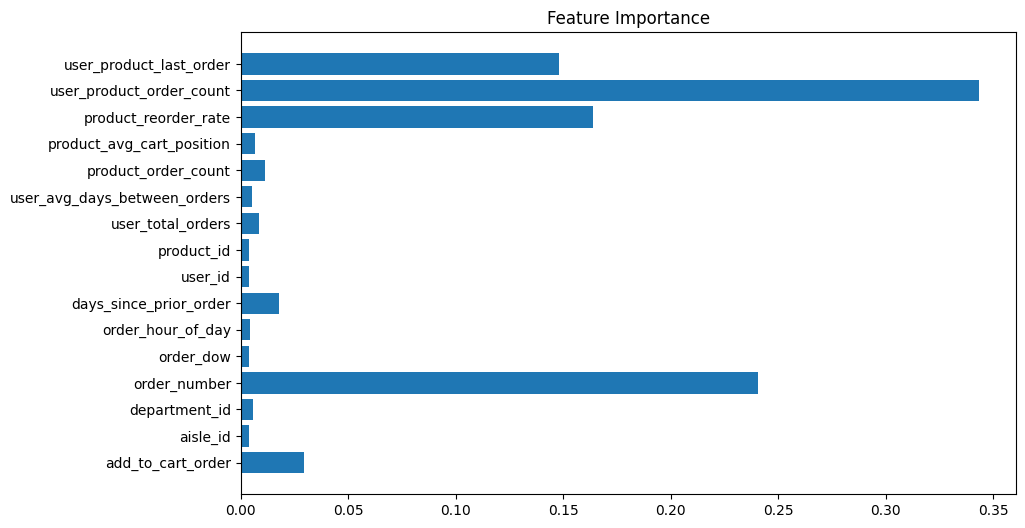

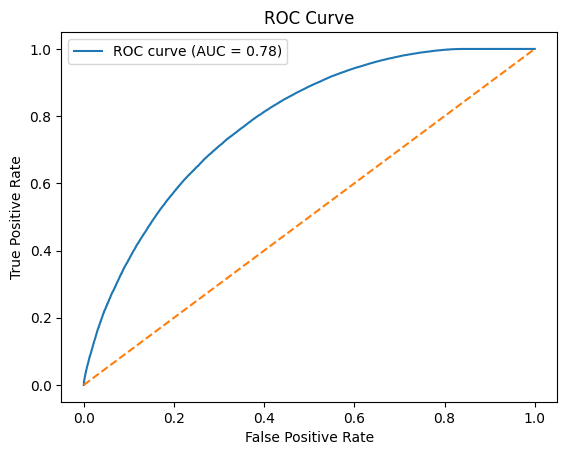

In [14]:
model = pipe_reorder.named_steps["model"]

importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()


y_proba = model.predict_proba(X_test)[:,1]
false_positives_rate, true_positives_rate, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.plot(false_positives_rate, true_positives_rate, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Graphic 1: Feature Importance

This graph shows the importance of each feature used by the model.  
Each bar represents one variable and how much it influences the prediction.

This graph helps us:
- understand **which features the model uses the most**
- see **which variables are not very useful**
- **detect possible data leakage**

Data leakage happens when the model uses information that should not be available for prediction. If one feature has **a very high importance**, it can be a sign that this variable leaks information from the target.

### Graphic 2: ROC Curve

This graph shows the performance of the model.

It compares:
- The **True Positive Rate**
- The **False Positive Rate**

The **AUC score** shows how good the model is at separating the two classes.
This graph helps us check if the model predicts well or not.